In [5]:
from pathlib import Path
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

INPUT_PATH = Path('DinamicaFinale1.xlsx')
START_DATE = pd.Timestamp('2026-01-27')
END_DATE = pd.Timestamp('2026-03-21')
TARGET_DATE = pd.Timestamp('2026-02-09')
VALUE_COLUMN = 'dynamic growth density (new links per node)'
DATE_COLUMN = 'day'

plt.style.use('default')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 12,
    'axes.labelsize': 21,
    'axes.titlesize': 13,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 16,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 1.0,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': '#d9d9d9',
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'grid.alpha': 0.8,
    'legend.frameon': False,
    'savefig.facecolor': 'white',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

In [ ]:

df = pd.read_excel(INPUT_PATH, sheet_name='daily_all_metrics', usecols=[DATE_COLUMN, VALUE_COLUMN])
df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN], errors='coerce').dt.normalize()
df[VALUE_COLUMN] = pd.to_numeric(df[VALUE_COLUMN], errors='coerce')
df = df.dropna(subset=[DATE_COLUMN, VALUE_COLUMN])


daily = (
    df.loc[df[DATE_COLUMN].between(START_DATE, END_DATE)]
      .groupby(DATE_COLUMN, as_index=False)[VALUE_COLUMN].mean()
 )
days = pd.DataFrame({DATE_COLUMN: pd.date_range(START_DATE, END_DATE, freq='D')})
daily = days.merge(daily, on=DATE_COLUMN, how='left')
daily[VALUE_COLUMN] = daily[VALUE_COLUMN].fillna(0.0)
daily = daily.rename(columns={DATE_COLUMN: 'day', VALUE_COLUMN: 'value'})

print(f'Days: {len(daily)} | Range: {daily.day.min().date()} -> {daily.day.max().date()}')
display(daily.head())

Giorni: 54 | Range: 2026-01-27 -> 2026-03-21


,day,value
0,2026-01-27,0.000000
1,2026-01-28,3.400000
2,2026-01-29,4.836910
3,2026-01-30,8.909405
4,2026-01-31,5.391037


In [ ]:
# Welch t-test for all cutoffs: (1,53), (2,52), ..., (53,1).
values = daily['value'].to_numpy(dtype=float)
dates = daily['day'].to_numpy()
results = []

for i in range(1, len(dates)):
    before, after = values[:i], values[i:]
    t_stat, p_value = ttest_ind(before, after, equal_var=False)
    results.append({
        'cutoff_date': dates[i],
        'mean_before': before.mean(),
        'mean_after': after.mean(),
        't_statistic': t_stat,
        'abs_t_statistic': abs(t_stat),
        'p_value': p_value,
        'n_before': len(before),
        'n_after': len(after),
    })

ttest_results = pd.DataFrame(results)
ttest_results['rank_by_abs_t'] = ttest_results['abs_t_statistic'].rank(ascending=False, method='min').astype('Int64')
ttest_results['rank_by_p_value'] = ttest_results['p_value'].rank(ascending=True, method='min').astype('Int64')
max_t_idx = ttest_results['abs_t_statistic'].idxmax()
min_p_idx = ttest_results['p_value'].idxmin()
max_row = ttest_results.loc[max_t_idx]
min_p_row = ttest_results.loc[min_p_idx]

print(f"Cutoff with maximum |t|: {max_row['cutoff_date'].date()} | |t|={max_row['abs_t_statistic']:.6f}")
print(f"Cutoff with minimum p-value: {min_p_row['cutoff_date'].date()} | p={min_p_row['p_value']:.6g}")

Cutoff con massimo |t|: 2026-02-09 | |t|=5.073421
Cutoff con minimo p-value: 2026-02-09 | p=0.000273481


RISULTATO CUTOFF 9 FEBBRAIO 2026
cutoff_date        2026-02-09 00:00:00
mean_before                    3.38138
mean_after                    0.030205
t_statistic                   5.073421
abs_t_statistic               5.073421
p_value                       0.000273
n_before                            13
n_after                             41
rank_by_abs_t                        1
rank_by_p_value                      1
Ranking |t|: 1 su 53
Ranking p-value: 1 su 53


,cutoff_date,mean_before,mean_after,t_statistic,abs_t_statistic,p_value,n_before,n_after,rank_by_abs_t,rank_by_p_value
12,2026-02-09,3.381380,0.030205,5.073421,5.073421,0.000273,13,41,1,1
11,2026-02-08,3.499188,0.076335,4.834108,4.834108,0.000511,12,42,2,4
13,2026-02-10,3.153376,0.026227,4.791452,4.791452,0.000352,14,40,3,2
14,2026-02-11,2.947063,0.025395,4.553287,4.553287,0.000451,15,39,4,3
10,2026-02-07,3.577772,0.135834,4.453854,4.453854,0.001172,11,43,5,24
15,2026-02-12,2.766109,0.024700,4.372916,4.372916,0.000546,16,38,6,5
16,2026-02-13,2.605731,0.024295,4.229591,4.229591,0.000638,17,37,7,6
9,2026-02-06,3.702996,0.185600,4.169257,4.169257,0.002301,10,44,8,43
17,2026-02-14,2.463961,0.023474,4.118043,4.118043,0.000718,18,36,9,7
18,2026-02-15,2.337298,0.022505,4.027762,4.027762,0.000789,19,35,10,8


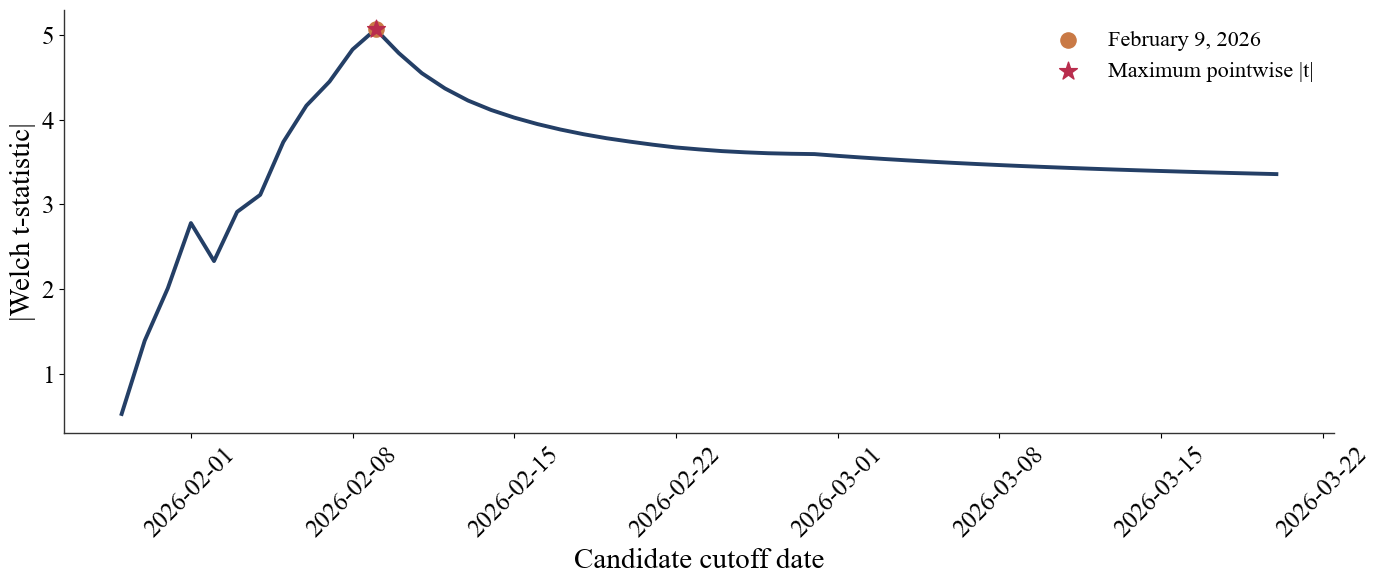

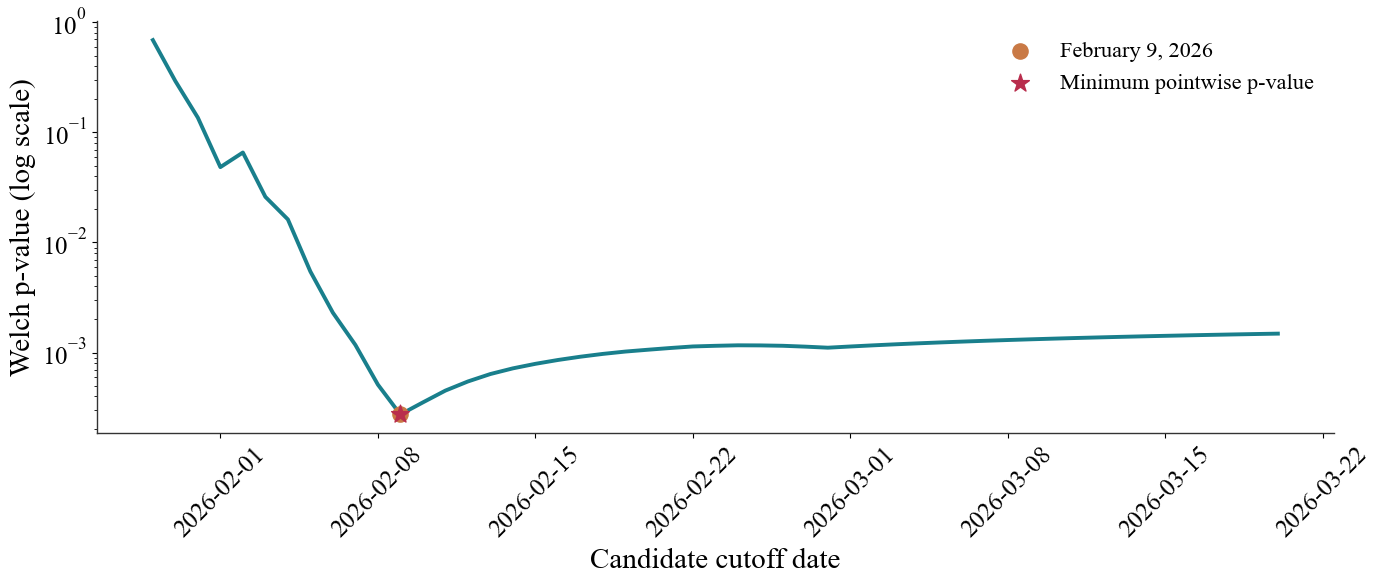

Risultati salvati in ttest2_results_dynamic_growth_density.csv


In [ ]:
# Highlight February 9, show the top 10, plot the charts, and save the results.
target = ttest_results.loc[ttest_results['cutoff_date'] == TARGET_DATE].iloc[0]
print('CUTOFF RESULT: FEBRUARY 9, 2026')
print(target.to_string())
print(f"Ranking by |t|: {target['rank_by_abs_t']} out of {len(ttest_results)}")
print(f"Ranking by p-value: {target['rank_by_p_value']} out of {len(ttest_results)}")

display(ttest_results.nlargest(10, 'abs_t_statistic'))

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ttest_results['cutoff_date'], ttest_results['abs_t_statistic'], color='#243f66', linewidth=2.8)
ax.scatter([TARGET_DATE], [target['abs_t_statistic']], color='#c97945', s=120, zorder=3, label='February 9, 2026')
ax.scatter([max_row['cutoff_date']], [max_row['abs_t_statistic']], color='#b92d4d', marker='*', s=180, zorder=3, label='Maximum pointwise |t|')
ax.set_xlabel('Candidate cutoff date', fontsize=21, fontweight='normal')
ax.set_ylabel('|Welch t-statistic|', fontsize=21, fontweight='normal')
ax.legend()
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.savefig('Figure5_ttest_breakpoint.png', dpi=150, bbox_inches='tight')
plt.savefig('Figure5_ttest_breakpoint.pdf', bbox_inches='tight')
plt.show()

# Plot the p-value for each cutoff.
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ttest_results['cutoff_date'], ttest_results['p_value'], color='#197f8c', linewidth=2.8)
ax.scatter([TARGET_DATE], [target['p_value']], color='#c97945', s=120, zorder=3, label='February 9, 2026')
ax.scatter([min_p_row['cutoff_date']], [min_p_row['p_value']], color='#b92d4d', marker='*', s=180, zorder=3, label='Minimum pointwise p-value')
ax.set_yscale('log')
ax.set_xlabel('Candidate cutoff date', fontsize=21, fontweight='normal')
ax.set_ylabel('Welch p-value (log scale)', fontsize=21, fontweight='normal')
ax.legend()
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.savefig('Figure5_ttest_pvalues.png', dpi=150, bbox_inches='tight')
plt.savefig('Figure5_ttest_pvalues.pdf', bbox_inches='tight')
plt.show()

export = ttest_results.copy()
export['cutoff_date'] = export['cutoff_date'].dt.strftime('%Y-%m-%d')
export.to_csv('ttest2_results_dynamic_growth_density.csv', index=False)
print('Results saved to ttest2_results_dynamic_growth_density.csv')